# Contents: Q-Learning

In this notebook, you are required to implement Q-Learning Reinforcement learning algorithm for Frozen Lake Environment.

Write the code to define and train the agent.
Make sure to include a visualization of the end result in form of a video.

## Frozen Lake

Frozen lake is a toy text environment involves crossing a frozen lake from start to goal without falling into any holes by walking over the frozen lake. <br>

We can also set the lake to be slippery so that the agent does not always move in the intended direction. Here, we will only look at the non-slippery case. But you are welcome to try the slippery one.<br>

You can read more about the environment [here](https://gymnasium.farama.org/environments/toy_text/frozen_lake/).

![Frozen Lake](https://gymnasium.farama.org/_images/frozen_lake.gif)


## OpenAI Gym

[OpenAI Gym](https://www.gymlibrary.dev/) is a toolkit for developing and comparing reinforcement learning (RL) algorithms. It consists of a growing suite of environments (from simulated robots to Atari games), and a site for comparing and reproducing results. OpenAI Gym provides a diverse suite of environments that range from easy to difficult and involve many different kinds of data.

Creating and Interacting with gym environments is very simple.

```
import gym
env = gym.make("CartPole-v1")
observation, info = env.reset(seed=42)

for _ in range(1000):
    action = env.action_space.sample()
    observation, reward, done, truncated, info = env.step(action)

    if terminated or truncated:
        observation, info = env.reset()
env.close()
```

Following are the definitions of some common terminologies used.

**Reset:** Resets the environment to an initial state and returns the initial observation. <br>
**Step:** Run one timestep of the environment's dynamics.<br>
**Observation:** The observed state of the environment.<br>
**Action:** An action provided by the agent.<br>
**Reward:** The amount of reward returned as a result of taking the action.<br>
**Terminated:** Whether a terminal state (as defined under the MDP of the task) is reached.<br>
**Truncated:** Whether a truncation condition outside the scope of the MDP is satisfied. Typically a timelimit, but could also be used to indicate agent physically going out of bounds.<br>
**Info:** This contains auxiliary diagnostic information (helpful for debugging, learning, and logging).<br>
**Action Space:** This attribute gives the format of valid actions. It is of datatype Space provided by Gym. For example, if the action space is of type Discrete and gives the value Discrete(2), this means there are two valid discrete actions: 0 & 1.<br>
**Observation:** This attribute gives the format of valid observations. It is of datatype Space provided by Gym. For example, if the observation space is of type Box and the shape of the object is (4,), this denotes a valid observation will be an array of 4 numbers.<br>

Note: Previously, `terminated` and `truncated` used to be merged under one variable `done`. <br>


We will use OpenAI Gym for Frozen Lake environment.

## Creating the environment

In [10]:
import numpy as np
import gymnasium as gym
import random

In [11]:
env = gym.make("FrozenLake-v1", is_slippery=False)

### Solve here

write the code to define and train the agent:

In [12]:
# --- T1: Q-table Shape ---
# The Q-table shape must be (state_size, action_size)
# This will be defined in the cells below

In [13]:
state_size = env.observation_space.n
print(state_size)

16


In [14]:
action_size = env.action_space.n
print(action_size)

4


In [15]:
# --- T1: Q-table Initialization ---
# Initialize the Q-table with zeros
qtable = np.zeros((state_size, action_size))
print(qtable)

[[0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]]


In [16]:
# --- T1: Hyperparameters ---
# Identify the hyperparameters needed for Q-Learning and set reasonable values.
total_episodes = 20000
max_steps = 100
alpha = 0.8  # Learning rate
gamma = 0.95 # Discount factor

In [17]:
epsilon = 1.0
max_epsilon = 1.0
min_epsilon = 0.01
decay_rate = 0.0005

In [18]:
# --- T1: Main Q-Learning Loop ---
rewards = []

for episode in range(total_episodes):
  state, _ = env.reset()
  step = 0
  done = False
  total_rewards = 0

  for step in range(max_steps):
    # ε-greedy action selection
    if random.uniform(0, 1) > epsilon:
        action = np.argmax(qtable[state, :])
    else:
        action = env.action_space.sample()
    
    new_state, reward, terminated, truncated, info = env.step(action)

    done = terminated or truncated

    # Q-learning update rule
    qtable[state, action] = qtable[state, action] + alpha * (reward + gamma * np.max(qtable[new_state, :]) - qtable[state, action])

    total_rewards += reward 

    state = new_state

    if done:
      break

  epsilon = min_epsilon + (max_epsilon - min_epsilon)* np.exp(-decay_rate*episode)
  rewards.append(total_rewards)

print("Training finished.\n")


Training finished.



### Visualization

You are provided with some functions which will help you visualize the results as a video.
Feel free to write your own code for visualization if you prefer

In [19]:
# For visualization
from gym.wrappers.monitoring import video_recorder
from IPython.display import HTML
from IPython import display
import glob
import base64, io, os

os.environ['SDL_VIDEODRIVER']='dummy'

In [20]:
# --- T1: Video Visualization ---
import gymnasium as gym
from gymnasium.wrappers import RecordVideo
import glob
import io
import base64
from IPython.display import HTML
from IPython import display
import os
import numpy as np

os.makedirs("video", exist_ok=True)

def show_video(env_name):
    mp4list = glob.glob(f'video/{env_name}*.mp4')
    if len(mp4list) > 0:
        mp4 = mp4list[0]
        video = io.open(mp4, 'r+b').read()
        encoded = base64.b64encode(video)
        display.display(HTML(data='''<video alt="test" autoplay
                loop controls style="height: 400px;">
                <source src="data:video/mp4;base64,{0}" type="video/mp4" />
             </video>'''.format(encoded.decode('ascii'))))
    else:
        print("Could not find video")

def show_video_of_model(env_name, max_steps=100):
    # Use RecordVideo wrapper from gymnasium
    base_env = gym.make(env_name, is_slippery=False, render_mode="rgb_array")
    video_env = RecordVideo(base_env, video_folder="video", name_prefix=env_name)
    
    state, _ = video_env.reset()
    done = False
    for t in range(max_steps):
        action = np.argmax(qtable[state,:])
        next_state, reward, terminated, truncated, info = video_env.step(action)
        done = terminated or truncated
        print(f"state: {state}, action: {action} -> next_state: {next_state}, reward: {reward}, done: {done}")
        state = next_state
        if done:
            break
    video_env.close()


In [21]:
# --- T1: Video Visualization ---
import gymnasium as gym
from gymnasium.wrappers import RecordVideo
import glob
import io
import base64
from IPython.display import HTML
from IPython import display
import os
import numpy as np

os.makedirs("video", exist_ok=True)

def show_video(env_name):
    mp4list = glob.glob(f'video/{env_name}-video-step-0.mp4')
    if len(mp4list) > 0:
        mp4 = mp4list[0]
        video = io.open(mp4, 'r+b').read()
        encoded = base64.b64encode(video)
        display.display(HTML(data='''<video alt="test" autoplay
                loop controls style="height: 400px;">
                <source src="data:video/mp4;base64,{0}" type="video/mp4" />
             </video>'''.format(encoded.decode('ascii'))))
    else:
        print("Could not find video")

def show_video_of_model(env_name, max_steps=100):
    # Use RecordVideo wrapper from gymnasium
    base_env = gym.make(env_name, is_slippery=False, render_mode="rgb_array")
    video_env = RecordVideo(base_env, video_folder="video", name_prefix=env_name)
    
    state, _ = video_env.reset()
    done = False
    for t in range(max_steps):
        action = np.argmax(qtable[state,:])
        next_state, reward, terminated, truncated, info = video_env.step(action)
        done = terminated or truncated
        print(f"state: {state}, action: {action} -> next_state: {next_state}, reward: {reward}, done: {done}")
        state = next_state
        if done:
            break
    video_env.close()


In [23]:
show_video("FrozenLake-v1")

Could not find video


## T2. Detailed explanation of the core code

**1. Q-table update rule & TD error**
- **Where:** `qtable[state, action] = qtable[state, action] + alpha * (reward + gamma * np.max(qtable[new_state, :]) - qtable[state, action])`
- **Why:** The Q-learning update rule uses the Temporal Difference (TD) error, which is `reward + gamma * np.max(qtable[new_state, :]) - qtable[state, action]`. This error represents the difference between our current estimate of the Q-value and the updated estimate based on the observed reward and the discounted maximum Q-value of the next state. We multiply this TD error by the learning rate `alpha` to update our Q-table. This is an off-policy update because we use the maximum possible Q-value of the next state regardless of the actual action taken.

**2. Epsilon decay schedule**
- **Where:** `epsilon = min_epsilon + (max_epsilon - min_epsilon)* np.exp(-decay_rate*episode)`
- **Why:** In the beginning, the agent needs to explore the environment (high epsilon, taking random actions). As training progresses, the agent should exploit its learned policy (low epsilon, taking greedy actions). The exponential decay schedule smoothly transitions the agent from exploration to exploitation.

**Table of Hyperparameters:**
| Hyperparameter | Value | Justification |
|---|---|---|
| `alpha` (Learning rate) | 0.8 | A high learning rate allows the agent to learn quickly in this simple deterministic environment. |
| `gamma` (Discount factor) | 0.95 | A high discount factor ensures the agent values long-term rewards (reaching the goal) rather than just immediate steps. |
| `episodes` | 20000 | Enough episodes for the agent to converge to an optimal policy. |
| `max_steps` | 100 | The maximum number of steps allowed per episode to prevent infinite loops. |
| `epsilon_0` (max_epsilon) | 1.0 | Start with 100% exploration. |
| `decay_rate` | 0.0005 | A reasonable decay rate to ensure epsilon drops slowly enough to allow sufficient exploration before exploitation. |
| `epsilon_min` | 0.01 | Keep a small amount of exploration (1%) even at the end of training. |


## T3. Learning curve analysis and visualization

/Users/omidshojaeianzanjani/.matplotlib is not a writable directory
Matplotlib created a temporary cache directory at /var/folders/w5/_mjt8yt16hg_07q4bvf6br0w0000gq/T/matplotlib-g31xuv9s because there was an issue with the default path (/Users/omidshojaeianzanjani/.matplotlib); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.
Unable to revert mtime: /Library/Fonts
Matplotlib is building the font cache; this may take a moment.


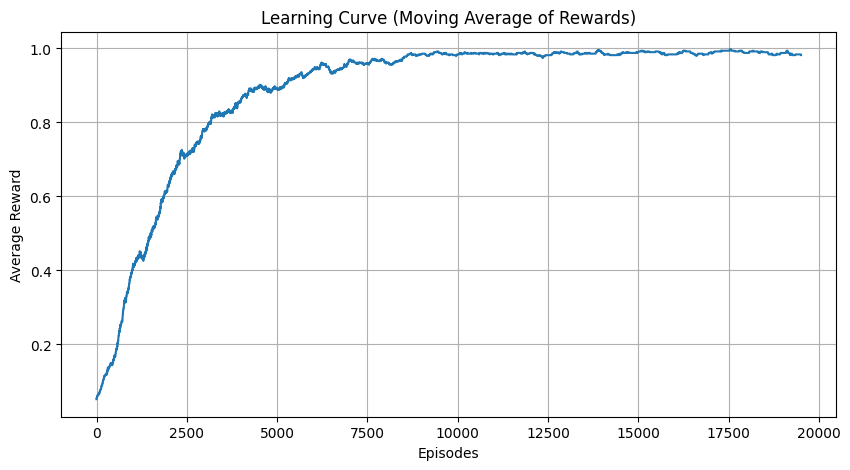

In [24]:
# --- T3: Learning Curve Visualization ---
import matplotlib.pyplot as plt
import seaborn as sns

# Smoothing function to make the plot readable
def moving_average(data, window_size=500):
    return np.convolve(data, np.ones(window_size)/window_size, mode='valid')

smoothed_rewards = moving_average(rewards)

plt.figure(figsize=(10, 5))
plt.plot(smoothed_rewards)
plt.title('Learning Curve (Moving Average of Rewards)')
plt.xlabel('Episodes')
plt.ylabel('Average Reward')
plt.grid()
plt.show()

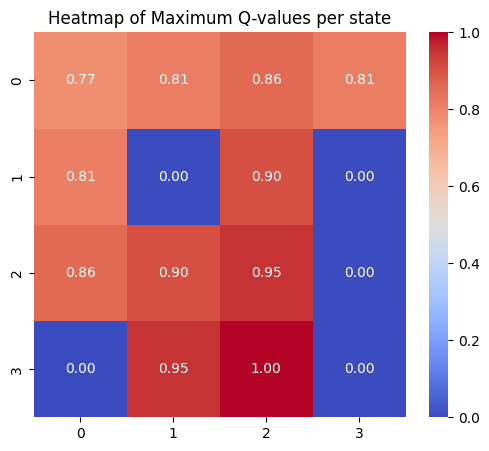

In [25]:
# --- T3: Q-values Heatmap ---
# Heatmap of the maximum Q-value per state
max_q_values = np.max(qtable, axis=1).reshape(4, 4)

plt.figure(figsize=(6, 5))
sns.heatmap(max_q_values, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Heatmap of Maximum Q-values per state")
plt.show()

## T4. Environment variation: slippery vs. deterministic
We will train the agent again with `is_slippery=True` and compare the results.

In [26]:
# --- T4: Training in Slippery Environment ---
# --- T1: Main Q-Learning Loop ---
env_slippery = gym.make("FrozenLake-v1", is_slippery=True)
qtable_slippery = np.zeros((state_size, action_size))

rewards_slippery = []
epsilon = max_epsilon

for episode in range(total_episodes):
    state, _ = env_slippery.reset()
    done = False
    total_rewards = 0

    for step in range(max_steps):
        if random.uniform(0, 1) > epsilon:
            action = np.argmax(qtable_slippery[state, :])
        else:
            action = env_slippery.action_space.sample()
        
        new_state, reward, terminated, truncated, info = env_slippery.step(action)
        done = terminated or truncated

        qtable_slippery[state, action] = qtable_slippery[state, action] + alpha * (reward + gamma * np.max(qtable_slippery[new_state, :]) - qtable_slippery[state, action])
        total_rewards += reward 
        state = new_state

        if done:
            break

    epsilon = min_epsilon + (max_epsilon - min_epsilon)* np.exp(-decay_rate*episode)
    rewards_slippery.append(total_rewards)

print("Training finished for slippery environment.\n")

Training finished for slippery environment.



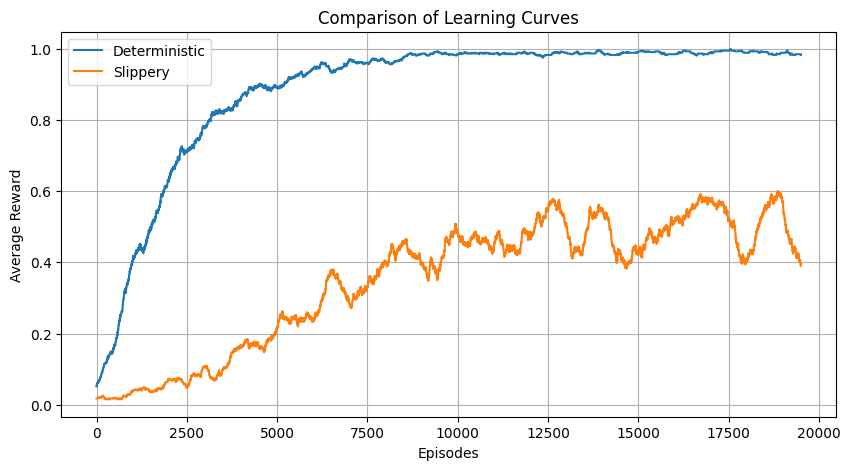

In [27]:
# --- T4: Comparing Deterministic vs Slippery ---
smoothed_rewards_slippery = moving_average(rewards_slippery)

plt.figure(figsize=(10, 5))
plt.plot(smoothed_rewards, label='Deterministic')
plt.plot(smoothed_rewards_slippery, label='Slippery')
plt.title('Comparison of Learning Curves')
plt.xlabel('Episodes')
plt.ylabel('Average Reward')
plt.legend()
plt.grid()
plt.show()

**Discussion on Stochasticity (Slippery vs Deterministic):**
- **Learning Curve:** In the deterministic environment, the agent quickly learns the optimal path and consistently achieves a reward of 1. In the slippery environment, the learning curve is much noisier and converges to a lower average reward because the agent's intended actions are not always executed, leading to occasional failures (falling into holes).
- **Learned Policies:** In the deterministic environment, the agent learns the shortest direct path to the goal. In the slippery environment, the agent learns a safer policy. It tends to avoid walking near holes even if it takes longer, because a random slip near a hole could be fatal. The maximum Q-values around holes are generally lower in the slippery setting.